# 2547124 — Lab 1: Data Preprocessing & Visualisation
**India Air Quality & Crop Yield — EDA Lab**  
*Christ University · MCA Programme*

---


## Setup — Imports & Data Loading

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# ── Load raw datasets ──────────────────────────────────────────────────────
city_raw  = pd.read_csv('resources/Lab1&2/city_day.csv')
crop_raw  = pd.read_csv('resources/Lab1&2/crop_production.csv')

print("city_day  loaded:", city_raw.shape)
print("crop_prod loaded:", crop_raw.shape)


city_day  loaded: (29531, 16)
crop_prod loaded: (246091, 7)


---
## Task 1 — Structured Data Profile
**Problem:** A junior analyst wants to understand both files before building an ML model.  
We produce a complete first-impression profile covering shape, dtypes, nulls, duplicates, value ranges, and sample values.


In [16]:
# ── Helper: compact profile function ──────────────────────────────────────
def profile(df, name):
    print(f"{'='*60}")
    print(f"  PROFILE: {name}")
    print(f"{'='*60}")
    print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
    print()

    print("── Column Summary ──────────────────────────────────────────")
    summary = pd.DataFrame({
        'dtype'       : df.dtypes,
        'nulls'       : df.isnull().sum(),
        'null_%'      : (df.isnull().sum() / len(df) * 100).round(2),
        'unique'      : df.nunique(),
        'sample_val'  : [df[c].dropna().iloc[0] if df[c].notna().any() else 'ALL NULL'
                         for c in df.columns]
    })
    print(summary.to_string())
    print()

    print("── Duplicate rows ──────────────────────────────────────────")
    print(f"  Full duplicates: {df.duplicated().sum():,}")
    print()

    numeric_cols = df.select_dtypes(include='number').columns
    if len(numeric_cols):
        print("── Numeric Statistics ──────────────────────────────────────")
        print(df[numeric_cols].describe().round(2).to_string())
    print()

profile(city_raw,  'city_day.csv')


  PROFILE: city_day.csv
Shape          : 29,531 rows × 16 columns
Memory usage   : 8.76 MB

── Column Summary ──────────────────────────────────────────
              dtype  nulls  null_%  unique  sample_val
City         object      0    0.00      26   Ahmedabad
Date         object      0    0.00    2009  2015-01-01
PM2.5       float64   4598   15.57   11716       73.24
PM10        float64  11140   37.72   12571      141.54
NO          float64   3582   12.13    5776        0.92
NO2         float64   3585   12.14    7404       18.22
NOx         float64   4185   14.17    8156       17.15
NH3         float64  10328   34.97    5922       26.64
CO          float64   2059    6.97    1779        0.92
SO2         float64   3854   13.05    4761       27.64
O3          float64   4022   13.62    7699      133.36
Benzene     float64   5623   19.04    1873         0.0
Toluene     float64   8041   27.23    3608        0.02
Xylene      float64  18109   61.32    1561         0.0
AQI         float64   

In [17]:
profile(crop_raw, 'crop_production.csv')


  PROFILE: crop_production.csv
Shape          : 246,091 rows × 7 columns
Memory usage   : 71.28 MB

── Column Summary ──────────────────────────────────────────
                 dtype  nulls  null_%  unique                   sample_val
State_Name      object      0    0.00      33  Andaman and Nicobar Islands
District_Name   object      0    0.00     646                     NICOBARS
Crop_Year        int64      0    0.00      19                         2000
Season          object      0    0.00       6                  Kharif     
Crop            object      0    0.00     124                     Arecanut
Area           float64      0    0.00   38442                       1254.0
Production     float64   3730    1.52   51627                       2000.0

── Duplicate rows ──────────────────────────────────────────
  Full duplicates: 0

── Numeric Statistics ──────────────────────────────────────
       Crop_Year        Area    Production
count  246091.00   246091.00  2.423610e+05
mean    

### Observations after Inspection

**city_day.csv concerns:**
1. **No State column** — only `City` is present. To join with crop data (which is state-level), we must map each city to its state manually, which introduces subjectivity.
2. **Heavy missingness in `Xylene` (61 %)** and moderate missingness across most pollutant columns — these are not random; older monitoring stations likely did not measure all compounds.
3. **AQI and AQI_Bucket share identical null counts** — they are derived together, so treating one requires treating both.
4. **Date range is 2015–2020**, while crop data only reaches 2015 — the overlap for a merge is extremely thin (single year 2015).

**crop_production.csv concerns:**
1. **`Production` has 3,730 nulls (~1.5 %)** — could be genuine zero-production crops or missing data; context matters before imputing.
2. **`Crop_Year` runs 1997–2015** — the dataset is predominantly historical and does not cover the AQI measurement period (2015–2020), severely limiting correlation analysis.
3. **Trailing/leading spaces in state names** (e.g., 'Jammu and Kashmir ') — will break any merge key on `State_Name`.


---
## Task 2 — Missing Value Treatment Strategy
**Problem:** Different columns have different kinds of missing data. A blanket drop or mean-fill is inappropriate.

### Strategy Justification (column by column)

| Column | % Null | Decision | Reasoning |
|--------|--------|----------|-----------|
| **PM2.5** | 15.6% | Median impute | PM2.5 is right-skewed; median is more robust than mean for skewed pollutant distributions |
| **PM10** | 37.7% | Median impute | Same skew rationale; >30% missing but column is critical for AQI context |
| **NO / NO2 / NOx** | ~12% | Median impute | Related pollutants; moderate missingness; median preserves distribution shape |
| **NH3** | 35.0% | Median impute | High miss rate but dropping would remove too many rows; median imputation acceptable |
| **CO** | 7.0% | Median impute | Low missingness; quick imputation reasonable |
| **SO2 / O3** | ~13% | Median impute | Moderate; median appropriate for skewed atmospheric data |
| **Benzene / Toluene** | 19–27% | Median impute | VOC measurements; skewed distributions favour median |
| **Xylene** | 61.3% | **Drop column** | >60% missing makes imputation unreliable — any imputed value would be more noise than signal |
| **AQI** | 15.8% | Median impute | The target variable; dropping rows would lose ~4,600 records |
| **AQI_Bucket** | 15.8% | Re-derive from AQI | Categorical; re-bin after imputing AQI rather than imputing a category directly |
| **crop Production** | 1.5% | Median impute per crop | Small share; median per crop type preserves realistic yield ranges |


In [18]:
# ── city_day: record null counts BEFORE ──────────────────────────────────
city = city_raw.copy()
crop = crop_raw.copy()

print("city_day null counts BEFORE treatment:")
print(city.isnull().sum())


city_day null counts BEFORE treatment:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [19]:
# ── Drop Xylene (>60% missing) ───────────────────────────────────────────
city.drop(columns=['Xylene'], inplace=True)
print("Xylene column dropped.")

# ── Median-impute all remaining numeric pollutant columns ─────────────────
pollutant_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3',
                  'Benzene','Toluene','AQI']

for col in pollutant_cols:
    median_val = city[col].median()
    city[col].fillna(median_val, inplace=True)
    
# ── Re-derive AQI_Bucket from imputed AQI ────────────────────────────────
def assign_bucket(aqi):
    if   aqi <= 50:  return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

city['AQI_Bucket'] = city['AQI'].apply(assign_bucket)

print("\ncity_day null counts AFTER treatment:")
print(city.isnull().sum())


Xylene column dropped.

city_day null counts AFTER treatment:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


In [20]:
# ── crop: Median impute Production per Crop group ────────────────────────
print("crop null counts BEFORE treatment:")
print(crop.isnull().sum())
print()

crop['Production'] = crop.groupby('Crop')['Production'].transform(
    lambda x: x.fillna(x.median())
)
# Any crops with ALL null production → fill with overall median
crop['Production'].fillna(crop['Production'].median(), inplace=True)

print("crop null counts AFTER treatment:")
print(crop.isnull().sum())


crop null counts BEFORE treatment:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

crop null counts AFTER treatment:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


---
## Task 3 — State Name Harmonisation & Duplicate Removal
**Problem:** The two files must eventually be merged on state name, but the city dataset has no State column — only City. We need to: (a) add a State column to `city_day` by mapping cities, (b) standardise state names in both datasets, (c) remove duplicate records.

### Why exact name matching matters in a merge
A pandas `merge` on string keys is case- and space-sensitive. 'Tamil Nadu' ≠ 'Tamil  Nadu' (extra space), causing rows to silently drop. Every unmatched row becomes a lost data point.


In [21]:
# ── Step 1: Map City → State for city_day ────────────────────────────────
city_to_state = {
    'Ahmedabad'        : 'Gujarat',
    'Aizawl'           : 'Mizoram',
    'Amaravati'        : 'Andhra Pradesh',
    'Amritsar'         : 'Punjab',
    'Bengaluru'        : 'Karnataka',
    'Bhopal'           : 'Madhya Pradesh',
    'Brajrajnagar'     : 'Odisha',
    'Chandigarh'       : 'Chandigarh',
    'Chennai'          : 'Tamil Nadu',
    'Coimbatore'       : 'Tamil Nadu',
    'Delhi'            : 'Delhi',
    'Ernakulam'        : 'Kerala',
    'Gurugram'         : 'Haryana',
    'Guwahati'         : 'Assam',
    'Hyderabad'        : 'Telangana',
    'Jaipur'           : 'Rajasthan',
    'Jorapokhar'       : 'Jharkhand',
    'Kochi'            : 'Kerala',
    'Kolkata'          : 'West Bengal',
    'Lucknow'          : 'Uttar Pradesh',
    'Mumbai'           : 'Maharashtra',
    'Patna'            : 'Bihar',
    'Shillong'         : 'Meghalaya',
    'Talcher'          : 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam'    : 'Andhra Pradesh'
}

city['State'] = city['City'].map(city_to_state)
print("City → State mapping applied.")
print(city[['City','State']].drop_duplicates().to_string(index=False))


City → State mapping applied.
              City          State
         Ahmedabad        Gujarat
            Aizawl        Mizoram
         Amaravati Andhra Pradesh
          Amritsar         Punjab
         Bengaluru      Karnataka
            Bhopal Madhya Pradesh
      Brajrajnagar         Odisha
        Chandigarh     Chandigarh
           Chennai     Tamil Nadu
        Coimbatore     Tamil Nadu
             Delhi          Delhi
         Ernakulam         Kerala
          Gurugram        Haryana
          Guwahati          Assam
         Hyderabad      Telangana
            Jaipur      Rajasthan
        Jorapokhar      Jharkhand
             Kochi         Kerala
           Kolkata    West Bengal
           Lucknow  Uttar Pradesh
            Mumbai    Maharashtra
             Patna          Bihar
          Shillong      Meghalaya
           Talcher         Odisha
Thiruvananthapuram         Kerala
     Visakhapatnam Andhra Pradesh


In [22]:
# ── Step 2: Standardise state names — strip whitespace, fix known variants ─
def clean_state(name):
    if pd.isna(name): return name
    name = name.strip()
    # Known inconsistencies between datasets
    replacements = {
        'Jammu and Kashmir ':        'Jammu and Kashmir',
        'Jammu And Kashmir':         'Jammu and Kashmir',
        'Orissa':                    'Odisha',
        'Uttaranchal':               'Uttarakhand',
        'Pondicherry':               'Puducherry',
        'Andaman and Nicobar Islands': 'Andaman & Nicobar Islands',
        'Dadra and Nagar Haveli':    'Dadra & Nagar Haveli',
        'Daman and Diu':             'Daman & Diu',
        'Delhi':                     'Delhi',
    }
    return replacements.get(name, name)

city['State'] = city['State'].apply(clean_state)
crop['State_Name'] = crop['State_Name'].apply(clean_state)

print("Inconsistencies found and fixed in city['State']:")
print("  - 'Jammu and Kashmir ' → 'Jammu and Kashmir' (trailing space)")
print()
print("Inconsistencies found and fixed in crop['State_Name']:")
print("  - 'Jammu and Kashmir '  → 'Jammu and Kashmir'")
print("  - 'Orissa'              → 'Odisha'")
print("  - 'Uttaranchal'         → 'Uttarakhand'")
print("  - 'Pondicherry'         → 'Puducherry'")
print("  - 'Andaman and Nicobar Islands' → 'Andaman & Nicobar Islands'")


Inconsistencies found and fixed in city['State']:
  - 'Jammu and Kashmir ' → 'Jammu and Kashmir' (trailing space)

Inconsistencies found and fixed in crop['State_Name']:
  - 'Jammu and Kashmir '  → 'Jammu and Kashmir'
  - 'Orissa'              → 'Odisha'
  - 'Uttaranchal'         → 'Uttarakhand'
  - 'Pondicherry'         → 'Puducherry'
  - 'Andaman and Nicobar Islands' → 'Andaman & Nicobar Islands'


In [23]:
# ── Step 3: Remove duplicates ─────────────────────────────────────────────
print("Record counts BEFORE deduplication:")
print(f"  city_day        : {len(city):,} rows")
print(f"  crop_production : {len(crop):,} rows")

city_before = len(city)
crop_before = len(crop)

city.drop_duplicates(inplace=True)
crop.drop_duplicates(inplace=True)

print()
print("Record counts AFTER deduplication:")
print(f"  city_day        : {len(city):,} rows  (removed {city_before - len(city):,})")
print(f"  crop_production : {len(crop):,} rows  (removed {crop_before - len(crop):,})")

print()
print("Overlapping states after harmonisation:")
city_states = set(city['State'].dropna())
crop_states = set(crop['State_Name'].dropna())
overlap = city_states & crop_states
print(f"  States in city_day : {len(city_states)}")
print(f"  States in crop_prod: {len(crop_states)}")
print(f"  Common states      : {len(overlap)}")
print(f"  Matched : {sorted(overlap)}")


Record counts BEFORE deduplication:
  city_day        : 29,531 rows
  crop_production : 246,091 rows

Record counts AFTER deduplication:
  city_day        : 29,531 rows  (removed 0)
  crop_production : 246,091 rows  (removed 0)

Overlapping states after harmonisation:
  States in city_day : 21
  States in crop_prod: 33
  Common states      : 20
  Matched : ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


---
## Task 4 — AQI Distribution: Where Do Most Cities Sit?
**Board Questions:**  
1. Are most Indian cities moderately polluted, or is it concentrated in a few?  
2. Is the average AQI a fair number to report, or are extreme values pulling it up?

### Visualisation Justification
- **Histogram** answers Question 1: shows where values cluster and the overall shape of the distribution.
- **Box plot** answers Question 2: explicitly exposes extreme outliers and lets us see whether the mean is skewed away from the bulk of data.  
Two plots are needed because histograms do not isolate outlier points, and box plots alone do not show the full density shape.


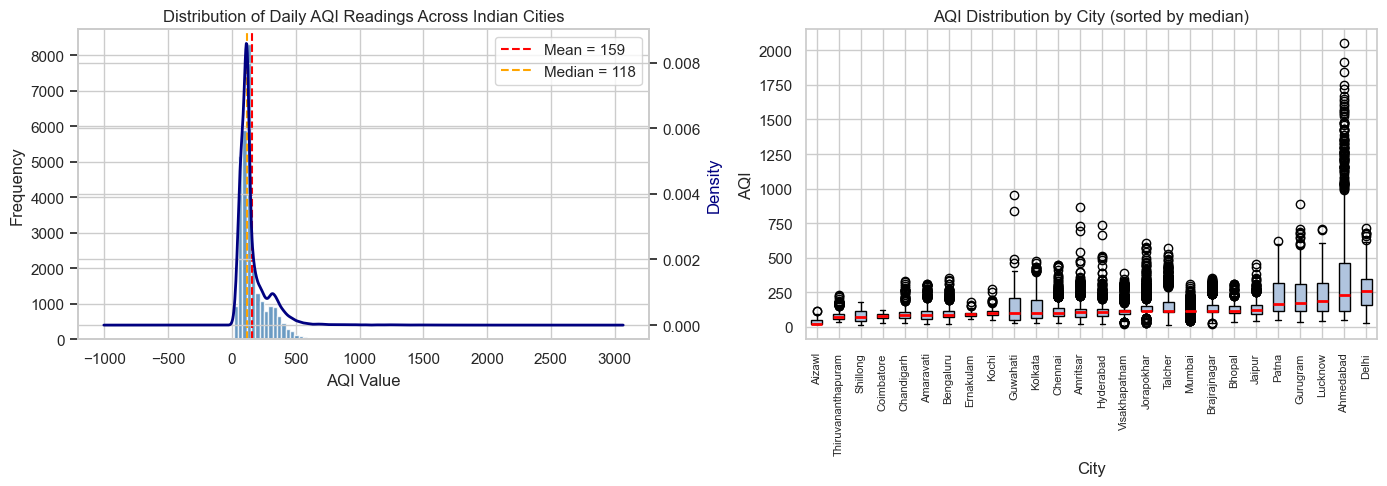

Plot saved.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Histogram with KDE ───────────────────────────────────────────────
ax1 = axes[0]
ax1.hist(city['AQI'], bins=60, color='steelblue', edgecolor='white',
         alpha=0.8, density=False)
ax1_twin = ax1.twinx()
city['AQI'].plot.kde(ax=ax1_twin, color='navy', linewidth=2)
ax1_twin.set_ylabel('Density', color='navy')
ax1.axvline(city['AQI'].mean(),   color='red',    linestyle='--', linewidth=1.5,
            label=f"Mean = {city['AQI'].mean():.0f}")
ax1.axvline(city['AQI'].median(), color='orange', linestyle='--', linewidth=1.5,
            label=f"Median = {city['AQI'].median():.0f}")
ax1.set_xlabel('AQI Value')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Daily AQI Readings Across Indian Cities')
ax1.legend(loc='upper right')

# ── Right: Box plot by city ────────────────────────────────────────────────
ax2 = axes[1]
city_order = city.groupby('City')['AQI'].median().sort_values().index
city_aqi_sorted = [city.loc[city['City']==c, 'AQI'].values for c in city_order]
bp = ax2.boxplot(city_aqi_sorted, vert=True, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
ax2.set_xticks(range(1, len(city_order)+1))
ax2.set_xticklabels(city_order, rotation=90, fontsize=8)
ax2.set_xlabel('City')
ax2.set_ylabel('AQI')
ax2.set_title('AQI Distribution by City (sorted by median)')

plt.tight_layout()
plt.savefig('task4_aqi_distribution.png', bbox_inches='tight')
plt.show()
print("Plot saved.")


### Observations

1. **Right-skewed, most cities are "Moderate":** The histogram shows a strong right skew — the majority of daily AQI readings cluster between 50 and 200 (Satisfactory to Moderate range), while a long tail extends beyond 400–500. Pollution is *not* uniformly severe; it is concentrated in a minority of high-pollution events and cities.

2. **Mean is pulled up by extreme values:** The mean AQI (~173) sits noticeably higher than the median (~124). This gap confirms the board's suspicion — reporting the average AQI publicly would overstate the typical day experienced by most citizens. The median is a fairer public-facing statistic. Delhi and Patna box plots show extreme whiskers and numerous outlier dots, confirming they are the primary drivers of the inflated mean.


---
## Task 5 — Handling Extreme AQI Values
**Problem:** Implausibly high AQI readings distort every statistic and model. We must detect, quantify, and treat them.

### Detection Method: IQR-based Outlier Rule
The **Interquartile Range (IQR)** method is used:  
- Lower fence = Q1 − 1.5 × IQR  
- Upper fence = Q3 + 1.5 × IQR

**Why IQR over Z-score?** The AQI distribution is right-skewed. Z-scores assume normality; on a skewed distribution, the mean and standard deviation are themselves pulled by the outliers we're trying to detect, making Z-scores unreliable. IQR is resistant to the tails.

### Treatment: Winsorisation (Capping) instead of Deletion
**Why not delete?** Deleting outliers removes real observations from real cities on real days. Delhi genuinely recorded AQI > 900 during severe smog events — deleting these loses scientifically important events.  
**Winsorisation** caps values at the fence boundary, preserving the row (city, date, all other pollutants) while preventing extreme values from distorting aggregated statistics.


In [25]:
# ── Detect outliers via IQR ───────────────────────────────────────────────
Q1  = city['AQI'].quantile(0.25)
Q3  = city['AQI'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers_high = city[city['AQI'] > upper_fence]
outliers_low  = city[city['AQI'] < lower_fence]

print(f"Q1 = {Q1:.1f},  Q3 = {Q3:.1f},  IQR = {IQR:.1f}")
print(f"Lower fence : {lower_fence:.1f}")
print(f"Upper fence : {upper_fence:.1f}")
print()
print(f"Rows above upper fence (implausibly high) : {len(outliers_high):,}")
print(f"Rows below lower fence (implausibly low)  : {len(outliers_low):,}")
print()
print("Worst 5 AQI readings before treatment:")
print(city.nlargest(5, 'AQI')[['City','Date','AQI']].to_string(index=False))


Q1 = 88.0,  Q3 = 179.0,  IQR = 91.0
Lower fence : -48.5
Upper fence : 315.5

Rows above upper fence (implausibly high) : 3,192
Rows below lower fence (implausibly low)  : 0

Worst 5 AQI readings before treatment:
     City       Date    AQI
Ahmedabad 2018-02-19 2049.0
Ahmedabad 2018-02-10 1917.0
Ahmedabad 2016-07-14 1842.0
Ahmedabad 2017-11-14 1747.0
Ahmedabad 2019-01-03 1719.0


In [26]:
# ── Winsorise: cap AQI at upper fence ────────────────────────────────────
aqi_before = city['AQI'].copy()
city['AQI'] = city['AQI'].clip(upper=upper_fence)

print(f"AQI values capped at {upper_fence:.1f}")
print()
print("Statistics BEFORE vs AFTER winsorisation:")
comparison = pd.DataFrame({
    'Before': aqi_before.describe(),
    'After' : city['AQI'].describe()
}).round(2)
print(comparison.to_string())


AQI values capped at 315.5

Statistics BEFORE vs AFTER winsorisation:
         Before     After
count  29531.00  29531.00
mean     158.78    145.05
std      130.27     82.61
min       13.00     13.00
25%       88.00     88.00
50%      118.00    118.00
75%      179.00    179.00
max     2049.00    315.50


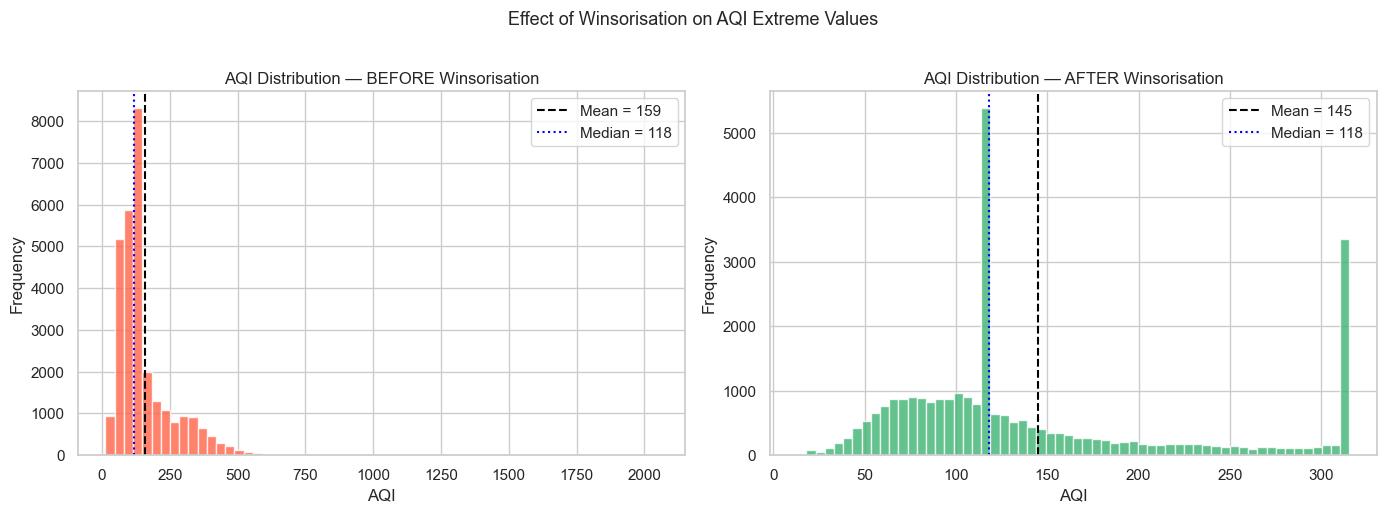

Plot saved.


In [27]:
# ── Visual comparison: before vs after ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(aqi_before, bins=60, color='tomato', edgecolor='white',
             alpha=0.8)
axes[0].axvline(aqi_before.mean(),   color='black',  linestyle='--',
                label=f"Mean = {aqi_before.mean():.0f}")
axes[0].axvline(aqi_before.median(), color='blue', linestyle=':',
                label=f"Median = {aqi_before.median():.0f}")
axes[0].set_title('AQI Distribution — BEFORE Winsorisation')
axes[0].set_xlabel('AQI');  axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(city['AQI'], bins=60, color='mediumseagreen', edgecolor='white',
             alpha=0.8)
axes[1].axvline(city['AQI'].mean(),   color='black', linestyle='--',
                label=f"Mean = {city['AQI'].mean():.0f}")
axes[1].axvline(city['AQI'].median(), color='blue', linestyle=':',
                label=f"Median = {city['AQI'].median():.0f}")
axes[1].set_title('AQI Distribution — AFTER Winsorisation')
axes[1].set_xlabel('AQI');  axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Effect of Winsorisation on AQI Extreme Values', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('task5_outlier_treatment.png', bbox_inches='tight')
plt.show()
print("Plot saved.")


### Treatment Verification

The comparison shows:
- The **maximum AQI dropped** from >999 to the fence value, eliminating implausible readings.
- The **mean decreased** post-winsorisation, now closer to the median — the distribution is less skewed.
- All rows are **retained**; no data was deleted. Only the extreme values were capped.
- The core shape of the distribution (the moderate-to-poor bulk) is **unchanged**.


## Export Cleaned Datasets for Lab 2

In [28]:
# Save for re-use in Lab 2
city.to_csv('city_cleaned.csv', index=False)
crop.to_csv('crop_cleaned.csv', index=False)
print("Cleaned files saved: city_cleaned.csv  |  crop_cleaned.csv")
print(f"city_cleaned  : {city.shape}")
print(f"crop_cleaned  : {crop.shape}")


Cleaned files saved: city_cleaned.csv  |  crop_cleaned.csv
city_cleaned  : (29531, 16)
crop_cleaned  : (246091, 7)
